In [26]:
import numpy as np
from rdkit.Chem import rdFMCS
from rdkit import Chem
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem import AllChem
from rdkit.Geometry import Point3D
import math
from IPython.display import Image, display

from rdkit.Chem.Draw import rdMolDraw2D



In [2]:
reflections = [
    np.diag([sx, sy, sz])
    for sx in (-1, 1)
    for sy in (-1, 1)
    for sz in (-1, 1)
    if sx * sy * sz == -1
]


def get_coords(mol, conf_id=0):
    conf = mol.GetConformer(conf_id)
    return np.array([
        [conf.GetAtomPosition(i).x,
         conf.GetAtomPosition(i).y,
         conf.GetAtomPosition(i).z]
        for i in range(mol.GetNumAtoms())
    ])

def reflect_coords(coords, R):
    centroid = coords.mean(axis=0)
    return (coords - centroid) @ R.T + centroid

def set_coords(mol, coords, conf_id=0):
    conf = mol.GetConformer(conf_id)
    for i, (x, y, z) in enumerate(coords):
        conf.SetAtomPosition(i, Point3D(float(x), float(y), float(z)))

def xyz_to_rdkit_mol(xyz_file, total_charge):

    with open(xyz_file) as f:
        lines = f.readlines()[2:]  # skip atom count + comment
    atoms, coords = [], []
    for line in lines:
        parts = line.split()
        atoms.append(parts[0])
        coords.append([float(x) for x in parts[1:4]])
    coords = np.array(coords)
    
    # --- Create empty molecule with atoms ---
    mol = Chem.RWMol()
    z = [Chem.GetPeriodicTable().GetAtomicNumber(a) for a in atoms]
    for Zi in z:
        mol.AddAtom(Chem.Atom(Zi))
    
    # --- Add coordinates ---
    conf = Chem.Conformer(len(coords))
    for i, pos in enumerate(coords):
        conf.SetAtomPosition(i, pos)
    mol.AddConformer(conf)
    
    # --- Determine connectivity using RDKit's bond perception ---
    Chem.rdDetermineBonds.DetermineConnectivity(mol, charge=total_charge)
    
    # --- Sanitize molecule ---
    Chem.SanitizeMol(mol)
    
    return mol

In [63]:
mol1 = xyz_to_rdkit_mol('/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/PhotoStats/data/raw_geometries/meci/ethylene/0000_2.xyz', total_charge=0)
mol2 = xyz_to_rdkit_mol('/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/PhotoStats/data/raw_geometries/spawn/ethylene/0020_2.xyz', total_charge=0)

mols = [mol1,mol2]
res=rdFMCS.FindMCS(mols)
res_smarts= res.smartsString

mcs = Chem.MolFromSmarts(res_smarts)


In [68]:

matches1 = mol1.GetSubstructMatches(mcs, uniquify=False)
matches2 = mol2.GetSubstructMatches(mcs, uniquify=False)

best_rmsd = float("inf")
best_mol = None

orig_coords = get_coords(mol2)
rmsds = [ ]
for R in reflections:
    mol2_copy = Chem.Mol(mol2)
    coords = get_coords(mol2_copy)

    reflected = reflect_coords(coords, R)
    set_coords(mol2_copy, reflected)

    for m1 in matches1:
        for m2 in matches2:
            atom_map = list(zip(m2, m1))

            test_mol = Chem.Mol(mol2_copy)
            rmsd = AllChem.AlignMol(
                test_mol,
                mol1,
                atomMap=atom_map
            )
            rmsds.append(rmsd)

            if rmsd < best_rmsd:
                best_rmsd = rmsd
                best_mol = test_mol
                best_map = atom_map


rmsds.sort()
print(rmsds)

[0.30588468074644526, 0.30588468074644637, 0.30588468074644753, 0.30588468074644753, 0.30588468074644753, 0.30588468074644987, 0.30588468074644987, 0.3058846807464522, 0.32453966603116474, 0.32453966603116474, 0.3245396660311691, 0.3245396660311691, 0.32453966603117024, 0.3245396660311713, 0.3245396660311724, 0.3245396660311735, 0.39862000921025526, 0.39862000921025703, 0.3986200092102588, 0.3986200092102588, 0.39862000921026064, 0.39862000921026064, 0.3986200092103016, 0.3986200092103016, 0.4041972178960942, 0.4041972178960942, 0.404197217896096, 0.4041972178960977, 0.40419721789609947, 0.40419721789609947, 0.40419721789693447, 0.40419721789693625, 0.4181756509067797, 0.4181756509067797, 0.41817565090678055, 0.4181756509067814, 0.4181756509067814, 0.4181756509067814, 0.4181756509067814, 0.4181756509067831, 0.42397522844742086, 0.4239752284474226, 0.42397522844742425, 0.4239752284474251, 0.4239752284474251, 0.4239752284474259, 0.4239752284474259, 0.4239752284474276, 0.4302126121572939,

In [22]:
print(atom_map)

[(5, 5), (3, 3), (4, 4), (0, 0), (2, 2)]


In [69]:
import py3Dmol
from rdkit.Chem import rdmolfiles

view = py3Dmol.view(width=500, height=400)

# Model 0: reference molecule (mol2)
view.addModel(rdmolfiles.MolToMolBlock(best_mol), "sdf")
view.setStyle({"model": 0}, {"stick": {"radius": 0.2, "color": "gray"}})

# Model 1: aligned molecule (mol1)
view.addModel(rdmolfiles.MolToMolBlock(mol1), "sdf")
view.setStyle({"model": 1}, {"stick": {"radius": 0.2, "color": "cyan"}})

# Add atom labels for indices on the aligned molecule
view.addStyle(
    {"model": 1},
    {"stick": {}, "label": {"text": "{index}", "fontSize": 10, "color": "red"}}
)

view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

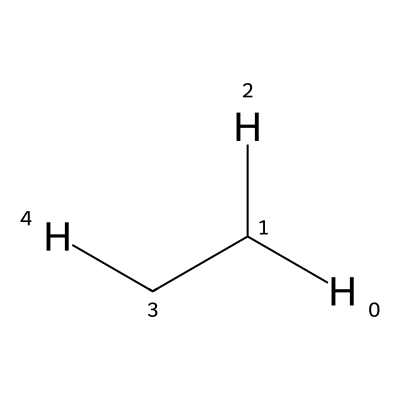

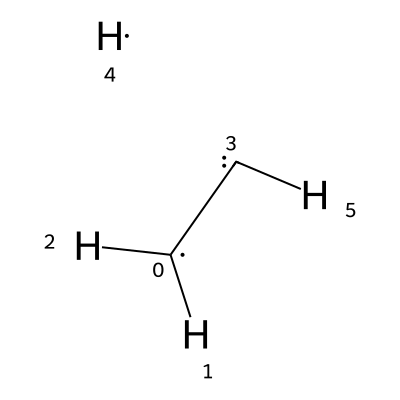

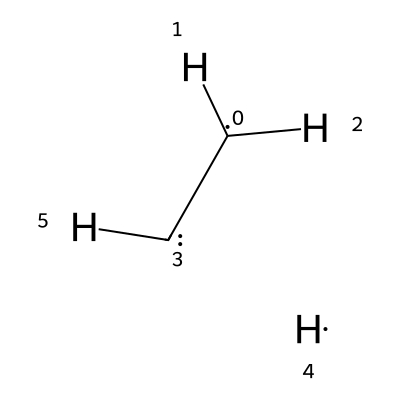

In [33]:

drawer = rdMolDraw2D.MolDraw2DCairo(400, 400)
opts = drawer.drawOptions()
opts.addAtomIndices = True

drawer.DrawMolecule(mcs)
drawer.FinishDrawing()

display(Image(drawer.GetDrawingText()))


drawer = rdMolDraw2D.MolDraw2DCairo(400, 400)
opts = drawer.drawOptions()
opts.addAtomIndices = True

drawer.DrawMolecule(mol2)
drawer.FinishDrawing()

display(Image(drawer.GetDrawingText()))


drawer = rdMolDraw2D.MolDraw2DCairo(400, 400)
opts = drawer.drawOptions()
opts.addAtomIndices = True

drawer.DrawMolecule(best_mol)
drawer.FinishDrawing()

display(Image(drawer.GetDrawingText()))

In [66]:
def numpy_geom(mol):
    conf = mol.GetConformer()
    return np.array([list(conf.GetAtomPosition(i)) for i in range(mol.GetNumAtoms())])

def write_xyz(filename, elems, coords, comment=""):
  
    coords = np.asarray(coords)

    if coords.shape[0] != len(elems):
        raise ValueError("Number of elements must match number of coordinates.")

    with open(filename, "w") as f:
        f.write(f"{len(elems)}\n")
        f.write(f"{comment}\n")
        for elem, (x, y, z) in zip(elems, coords):
            f.write(f"{elem} {x:.10f} {y:.10f} {z:.10f}\n")
            
mol1_geom = numpy_geom(mol1)
mol2_geom = numpy_geom(best_mol)

In [17]:
print(mol2_geom)

[[-1.81090667  0.4703036   0.10903768]
 [-1.03127279  2.3298634   0.76905184]
 [-2.61849908 -0.15350238 -0.163     ]
 [-0.69302092  1.33379567  0.48562069]
 [ 0.01527951  1.45581567 -0.33313768]
 [-0.13927558  0.92945796  1.3322312 ]]


In [54]:
from scipy.optimize import linear_sum_assignment
def get_coords(mol):
    conf = mol.GetConformer()
    return np.array([
        conf.GetAtomPosition(i)
        for i in range(mol.GetNumAtoms())
    ])


coords1 = get_coords(mol1)
coords2 = get_coords(best_mol)

n = mol1.GetNumAtoms()
assert n == best_mol.GetNumAtoms()

cost = np.zeros((n, n))

for i in range(n):
    a1 = mol1.GetAtomWithIdx(i)
    for j in range(n):
        a2 = best_mol.GetAtomWithIdx(j)

        # Forbid chemically invalid matches
        if a1.GetAtomicNum() != a2.GetAtomicNum():
            cost[i, j] = 1e6
        else:
            cost[i, j] = np.linalg.norm(coords1[i] - coords2[j])


row_ind, col_ind = linear_sum_assignment(cost)

new_order = col_ind[np.argsort(row_ind)]
mol2_reordered = Chem.RenumberAtoms(best_mol, new_order.tolist())

Chem.MolToXYZFile(mol1, str('/Users/connerbaucom/Desktop/Pieri/CTG/core/aligned/mol1.xyz'))
Chem.MolToXYZFile(mol2_reordered, str('/Users/connerbaucom/Desktop/Pieri/CTG/core/aligned/best_mol.xyz'))